<a href="https://colab.research.google.com/github/jenny005/geo-koopman/blob/main/koopman_cylinder_ablation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GeoKoop cylinder vortex shedding ablation

Companion to the pendulum ablation. Same five-condition structure, but
on cylinder vortex shedding (the system where your paper's strongest
rollout-error result lives — Figure 7 in the GeoKoop draft).

**Why this matters.** The pendulum ablation showed:
- `vec_pm` ≈ `geo` on rollout (parameter-matched vector residual ties the matrix form)
- `geo_nogeo` > `geo` on rollout (the regularizer hurts)
- mechanism plot ρ ≈ 0 or negative (N(z) doesn't track decoder anisotropy)

We need to know whether this pattern is specific to the pendulum (a small,
2D, lifted system) or reproduces on cylinder (a real PDE with native
spatial structure). The pendulum is the easy case for things going wrong;
cylinder is the hard case where the geometric framing has more room to
matter.

**Architecture** matches `koopman_cylinder_v2.py`:
- r = 32 SVD modes (data lives in R^32 after PCA)
- latent dim d = 16
- K initialized from DMD warm-start
- AE: 32 → 128 → 64 → 16 → 64 → 128 → 32
- lam_geo = 0.01 (matching v2, not the higher 0.05 from the older script)

**Parameter matching** (cylinder is much wider than pendulum):
| Model | correction hidden | correction params |
|---|---|---|
| GeoKoop | 64 | 21,888 |
| VecKoop param-matched | 132 | 21,928 |
| VecKoop width-matched | 64 | 6,288 |

The matrix vs vector parameter difference is large here (~15,600 params),
so this is a more demanding test of the structural claim than pendulum was.

**Expected runtime**: 5 conditions × 5 seeds = 25 runs at ~5-8 minutes each
on a T4 → roughly 2.5-3.5 hours wall clock. Checkpointing means session
disconnects only cost the in-progress run.


## 1. Mount Drive and set up paths

Output goes to `/content/drive/MyDrive/Koopman/Cylinder_data/results/`
(matches what you specified). Per-run JSONs go to `runs/`, plots to `figures/`.

The cylinder dataset must already be at:
`/content/drive/MyDrive/Koopman/Cylinder_data/DATA/FLUIDS/CYLINDER_ALL.mat`


In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/Koopman/Cylinder_data/DATA/FLUIDS/CYLINDER_ALL.mat'
SAVE_DIR  = '/content/drive/MyDrive/Koopman/Cylinder_data/results'
RUNS_DIR  = os.path.join(SAVE_DIR, 'runs')
FIGS_DIR  = os.path.join(SAVE_DIR, 'figures')
os.makedirs(RUNS_DIR, exist_ok=True)
os.makedirs(FIGS_DIR, exist_ok=True)

# Verify the data file exists before going further
assert os.path.exists(DATA_PATH), f'CYLINDER_ALL.mat not found at {DATA_PATH}'
print(f'Data:   {DATA_PATH}')
print(f'Output: {SAVE_DIR}')
print(f'Existing runs: {len(os.listdir(RUNS_DIR))}')

Mounted at /content/drive
Data:   /content/drive/MyDrive/Koopman/Cylinder_data/DATA/FLUIDS/CYLINDER_ALL.mat
Output: /content/drive/MyDrive/Koopman/Cylinder_data/results
Existing runs: 0


## 2. Imports and config

Hyperparameters match `koopman_cylinder_v2.py` exactly. The only addition
is the seed list and the parameter-matched VecKoop hidden width (132).


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import scipy.io
import json
import time
from collections import defaultdict

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')

# Sweep
SEEDS         = [0, 1, 2, 3, 4]
EPS           = 1.0                # fixed (Option B), same as pendulum
LAM_GEO       = 0.01               # matches v2.py

# Architecture (matches v2.py)
R             = 32                 # SVD modes for data compression
N_TRAIN       = 140                # training window
LATENT_DIM    = 16
HIDDEN_GEO    = 64
HIDDEN_VEC_WM = 64                 # width-matched (fewer params)
HIDDEN_VEC_PM = 132                # param-matched: yields 21,928 params ≈ geo's 21,888

# Training schedule (matches v2.py)
EPOCHS_P1     = 500                # phase 1: recon-only warmup
EPOCHS_P2     = 3000               # phase 2: full loss with rollout
ROLLOUT_K     = 20

# Learning rates (matches v2.py)
LR_AE         = 1e-3
LR_K          = 5e-5               # slow K updates
LR_CORR       = 5e-4

try:
    from torch.func import jacrev
    print('torch.func.jacrev available')
except ImportError:
    print('WARNING: torch.func.jacrev unavailable; mechanism plot will be skipped')

Device: cuda
PyTorch: 2.11.0+cu128
torch.func.jacrev available


## 3. Load and preprocess cylinder data

Same preprocessing as v2.py:
1. Load `VORTALL` from the .mat file (vorticity field over time)
2. Clip to [-10, 10], normalize globally
3. SVD-compress to top R=32 modes
4. Use first N_TRAIN=140 timesteps for training; the rest is held-out

Then compute the DMD matrix on the normalized SVD coordinates — this is
the warm-start for the Koopman matrix K in all conditions that have one.


In [3]:
data     = scipy.io.loadmat(DATA_PATH)
vort_all = data['VORTALL'].astype(np.float64)
vort_all = np.clip(vort_all, -10.0, 10.0)
vort_all = (vort_all - vort_all.mean()) / vort_all.std()
space_dim, T_total = vort_all.shape
NX, NY = 449, 199
print(f'Vorticity field: {space_dim} x {T_total}')

# SVD compression to R modes
U_svd, S_svd, Vt_svd = np.linalg.svd(vort_all, full_matrices=False)
X_reduced = U_svd[:, :R].T @ vort_all      # (R, T_total)
X_train   = X_reduced[:, :N_TRAIN]
X_mean    = X_train.mean(axis=1, keepdims=True)
X_std     = X_train.std(axis=1,  keepdims=True) + 1e-8
X_train_n = (X_train - X_mean) / X_std     # normalized SVD coords

print(f'SVD coords: {R} modes, train window: {N_TRAIN}')

# Move to GPU
X_torch = torch.tensor(X_train_n.T, dtype=torch.float32).to(device)  # (140, R)
x_t   = X_torch[:-1]                                                  # (139, R)
x_tp1 = X_torch[1:]                                                   # (139, R)

# DMD warm-start for K (same as v2.py)
def dmd_matrix_full(X):
    X1 = X[:, :-1]; X2 = X[:, 1:]
    U_, S_, Vt_ = np.linalg.svd(X1, full_matrices=False)
    r_ = min(20, len(S_))
    Ur = U_[:, :r_]; Sr = np.diag(S_[:r_]); Vr = Vt_[:r_].T
    A_tilde = Ur.T @ X2 @ Vr @ np.linalg.inv(Sr)
    return Ur @ A_tilde @ Ur.T

A_dmd_small = dmd_matrix_full(X_train_n)
print(f'DMD matrix computed, spectral radius: '
      f'{max(abs(np.linalg.eigvals(A_dmd_small))):.4f}')

Vorticity field: 89351 x 151
SVD coords: 32 modes, train window: 140
DMD matrix computed, spectral radius: 0.9826


## 4. Architecture

`AE` and `KoopmanCore` mirror v2.py's `AE` and `KoopmanCore`, with two
additions:
1. `mode='vec'` added to `KoopmanCore` (the ablation)
2. K can be DMD-initialized via `K_init` argument (already in v2.py)

The width of the hidden layers matches v2.py exactly: AE uses 128/64
hidden widths, correction net uses 64.


In [4]:
class AE(nn.Module):
    """Same autoencoder for all conditions. Matches v2.py."""
    def __init__(self, input_dim=R, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128), nn.Tanh(),
            nn.Linear(128, 64),        nn.Tanh(),
            nn.Linear(64, latent_dim))
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.Tanh(),
            nn.Linear(64, 128),        nn.Tanh(),
            nn.Linear(128, input_dim))
    def encode(self, x): return self.encoder(x)
    def decode(self, z): return self.decoder(z)


class KoopmanCore(nn.Module):
    """Unified core: deep / vec / geo modes.

    Same structure as the pendulum notebook, but with DMD warm-start
    for K (matching v2.py).
    """
    def __init__(self, d=LATENT_DIM, mode='geo', hidden=64, eps=1.0, K_init=None):
        super().__init__()
        assert mode in ('deep', 'vec', 'geo')
        self.d, self.mode, self.eps = d, mode, eps

        # DMD warm-start: use top-d-by-d block of the DMD matrix.
        # All three modes get the same K initialization for fairness.
        if K_init is not None:
            K0 = torch.tensor(K_init[:d, :d], dtype=torch.float32)
        else:
            K0 = torch.eye(d)
        self.K = nn.Parameter(K0)

        if mode == 'geo':
            self.correction = nn.Sequential(
                nn.Linear(d, hidden), nn.Tanh(),
                nn.Linear(hidden, hidden), nn.Tanh(),
                nn.Linear(hidden, d * d))
            nn.init.zeros_(self.correction[-1].weight)
            nn.init.zeros_(self.correction[-1].bias)
        elif mode == 'vec':
            self.correction = nn.Sequential(
                nn.Linear(d, hidden), nn.Tanh(),
                nn.Linear(hidden, hidden), nn.Tanh(),
                nn.Linear(hidden, d))
            nn.init.zeros_(self.correction[-1].weight)
            nn.init.zeros_(self.correction[-1].bias)
        # mode == 'deep': no correction

    def forward(self, z):
        out = z @ self.K.T
        if self.mode == 'geo':
            B  = z.shape[0]
            Nz = self.correction(z).view(B, self.d, self.d)
            out = out + self.eps * torch.bmm(Nz, z.unsqueeze(-1)).squeeze(-1)
        elif self.mode == 'vec':
            out = out + self.eps * self.correction(z)
        return out

    def correction_norm(self, z):
        if self.mode == 'deep':
            return torch.tensor(0., device=z.device)
        B = z.shape[0]
        if self.mode == 'geo':
            Nz = self.correction(z).view(B, self.d * self.d)
            return torch.mean(torch.norm(Nz, dim=1))
        else:
            return torch.mean(torch.norm(self.correction(z), dim=1))


def spec_pen(K):
    ev = torch.linalg.eigvals(K.unsqueeze(0))
    return ((ev.abs() - 1.0) ** 2).mean()

## 5. Training function

Same two-phase schedule as v2.py:
- Phase 1 (epochs 0–499): recon + small dynamics weight + spec penalty
- Phase 2 (epochs 500–3499): full loss with 20-step rollout + geometry reg

Two differences from the pendulum training:
1. Smaller batch — only 139 training pairs from one trajectory, vs pendulum's 175k. So the train/val/test split is different — there's no separate validation set, and "test" is just the held-out portion of the same trajectory (t=141..150).
2. Validation criterion is just the training loss at the current step (since we don't have a val set), so best-checkpoint selection uses 1-step latent dynamics on the training data itself, evaluated periodically.

This matches v2.py's protocol. The rollout error on t=141..150 is the
real test metric.


In [5]:
def train(seed, mode, hidden_corr, lam_geo, eps=EPS, verbose=False):
    """Train one cylinder model. Returns dict with metrics + modules."""
    torch.manual_seed(seed)
    np.random.seed(seed)

    ae   = AE(input_dim=R, latent_dim=LATENT_DIM).to(device)
    koop = KoopmanCore(d=LATENT_DIM, mode=mode, hidden=hidden_corr,
                       eps=eps, K_init=A_dmd_small).to(device)

    params = [{'params': ae.parameters(), 'lr': LR_AE},
              {'params': [koop.K],        'lr': LR_K}]
    if mode != 'deep':
        params.append({'params': koop.correction.parameters(), 'lr': LR_CORR})

    opt = torch.optim.Adam(params)
    sch = torch.optim.lr_scheduler.StepLR(opt, step_size=1000, gamma=0.5)

    total_epochs = EPOCHS_P1 + EPOCHS_P2

    for ep in range(total_epochs):
        ae.train(); koop.train()
        opt.zero_grad()

        z     = ae.encode(x_t)
        z_nxt = ae.encode(x_tp1)
        loss_rec  = ((ae.decode(z) - x_t) ** 2).mean()
        loss_dyn  = ((koop(z) - z_nxt) ** 2).mean()
        loss_spec = spec_pen(koop.K)
        loss_geo  = koop.correction_norm(z)

        loss_roll = torch.tensor(0., device=device)
        if ep >= EPOCHS_P1:
            # Rollout from each starting position, ROLLOUT_K steps ahead
            z_roll = ae.encode(x_t[:-ROLLOUT_K]).detach()
            for k in range(ROLLOUT_K):
                z_roll = koop(z_roll)
                z_tgt  = ae.encode(x_t[k+1:k+1+z_roll.shape[0]]).detach()
                loss_roll = loss_roll + ((z_roll - z_tgt) ** 2).mean()
            loss_roll = loss_roll / ROLLOUT_K

        if ep < EPOCHS_P1:
            loss = loss_rec + 0.1 * loss_dyn + 0.01 * loss_spec
        else:
            loss = (loss_rec + 1.0 * loss_dyn + 0.5 * loss_roll
                    + 0.01 * loss_spec + lam_geo * loss_geo)

        loss.backward()
        nn.utils.clip_grad_norm_(
            list(ae.parameters()) + list(koop.parameters()), 0.5)
        opt.step(); sch.step()

        if verbose and ep % 500 == 0:
            print(f'    ep={ep:4d}  rec={loss_rec.item():.4f} '
                  f'dyn={loss_dyn.item():.4f} roll={loss_roll.item():.4f} '
                  f'geo={loss_geo.item():.4f}')

    # ── Evaluation: full rollout in observation space ────────────
    ae.eval(); koop.eval()
    with torch.no_grad():
        # Roll out from t=0, all the way to t=T_total
        x0     = torch.tensor(X_train_n[:, 0],
                              dtype=torch.float32).unsqueeze(0).to(device)
        z_curr = ae.encode(x0)
        preds  = [ae.decode(z_curr).cpu().numpy()]
        for _ in range(T_total - 1):
            z_curr = koop(z_curr)
            preds.append(ae.decode(z_curr).cpu().numpy())
        X_norm = np.vstack(preds).T                  # (R, T_total)
        X_svd  = X_norm * X_std + X_mean
        X_full = U_svd[:, :R] @ X_svd                # (space_dim, T_total)

        # Per-timestep error in vorticity space
        err = np.linalg.norm(vort_all - X_full, axis=0)

    # Test metrics: in-window (training fit) and out-of-window (extrapolation)
    err_train = err[:N_TRAIN].mean()
    err_ext   = err[N_TRAIN:].mean()
    err_late  = err[100:150].mean()                  # the figure's window

    n_params_corr = (sum(p.numel() for p in koop.correction.parameters())
                     if mode != 'deep' else 0)

    return {
        'err_full':     err.tolist(),                 # per-timestep error
        'err_train':    float(err_train),
        'err_ext':      float(err_ext),
        'err_late':     float(err_late),
        'n_params':     n_params_corr,
        'ae':           ae,
        'koop':         koop,
    }

## 6. Sweep with checkpointing and resume

Five conditions × 5 seeds = 25 runs. Each one is ~5-8 minutes on a T4.

**If Colab disconnects mid-sweep**, rerun this cell — it skips runs whose
JSON already exists in `RUNS_DIR`. You'll see "skipped: N" in the final
message.

**Watching the run**: each completed run prints `err_late` (mean
vorticity-space error over t=100..150). This is the headline metric —
roughly equivalent to what your paper's Figure 7 shows for that window.


In [6]:
CONDITIONS = [
    # (name,         mode,    hidden,         lam_geo)
    ('deep',         'deep',  None,           0.0),
    ('vec_wm',       'vec',   HIDDEN_VEC_WM,  LAM_GEO),
    ('vec_pm',       'vec',   HIDDEN_VEC_PM,  LAM_GEO),
    ('geo_nogeo',    'geo',   HIDDEN_GEO,     0.0),
    ('geo',          'geo',   HIDDEN_GEO,     LAM_GEO),
]


def run_path(cond, seed):
    return os.path.join(RUNS_DIR, f'{cond}__seed{seed}.json')


def save_run(cond, seed, result):
    blob = {k: v for k, v in result.items() if k not in ('ae', 'koop')}
    with open(run_path(cond, seed), 'w') as f:
        json.dump(blob, f, indent=2)


# Hold seed-0 geo models in RAM for the mechanism plot (cell 9).
# If the session disconnects, cell 9 retrains them as needed.
seed0_models = {}

t_sweep = time.time()
n_done, n_skip = 0, 0

for name, mode, hidden, lam in CONDITIONS:
    for seed in SEEDS:
        if os.path.exists(run_path(name, seed)):
            n_skip += 1
            continue
        t0 = time.time()
        r = train(seed=seed, mode=mode, hidden_corr=hidden, lam_geo=lam)
        save_run(name, seed, r)
        if seed == 0 and mode == 'geo':
            seed0_models[name] = r
        n_done += 1
        print(f'[{name:11s} seed={seed}]  '
              f'err_train={r["err_train"]:.3f}  '
              f'err_late={r["err_late"]:.3f}  '
              f'err_ext={r["err_ext"]:.3f}  '
              f'({time.time()-t0:.0f}s)')

print(f'\nSweep done. New: {n_done}, skipped: {n_skip}. '
      f'Total time: {(time.time()-t_sweep)/60:.1f} min')

[deep        seed=0]  err_train=130.154  err_late=155.986  err_ext=159.076  (64s)
[deep        seed=1]  err_train=157.311  err_late=153.013  err_ext=145.960  (54s)
[deep        seed=2]  err_train=150.221  err_late=158.765  err_ext=142.265  (59s)
[deep        seed=3]  err_train=146.256  err_late=147.567  err_ext=140.230  (54s)
[deep        seed=4]  err_train=147.973  err_late=152.805  err_ext=138.918  (55s)
[vec_wm      seed=0]  err_train=25.558  err_late=33.501  err_ext=29.844  (99s)
[vec_wm      seed=1]  err_train=176.681  err_late=270.692  err_ext=290.097  (98s)
[vec_wm      seed=2]  err_train=51.672  err_late=124.091  err_ext=153.764  (98s)
[vec_wm      seed=3]  err_train=18.160  err_late=14.976  err_ext=14.529  (98s)
[vec_wm      seed=4]  err_train=15.144  err_late=14.536  err_ext=10.463  (99s)
[vec_pm      seed=0]  err_train=25.813  err_late=39.250  err_ext=21.571  (100s)
[vec_pm      seed=1]  err_train=56.329  err_late=136.397  err_ext=150.874  (99s)
[vec_pm      seed=2]  err_tra

## 7. Summary table

Aggregates all 25 runs into per-condition means ± seed std. Three metrics:
- `err_train`: mean error in the training window (t=0..139)
- `err_late`:  mean error in t=100..150 (your paper's headline window)
- `err_ext`:   mean error in the extrapolation window (t=140..150)

`err_late` and `err_ext` are the load-bearing comparisons.


In [7]:
def load_all_runs():
    runs = defaultdict(list)
    for fn in sorted(os.listdir(RUNS_DIR)):
        if not fn.endswith('.json'): continue
        cond = fn.split('__')[0]
        with open(os.path.join(RUNS_DIR, fn)) as f:
            runs[cond].append(json.load(f))
    return runs


def summarize(runs):
    summary = {}
    for cond, lst in runs.items():
        errs = np.array([r['err_full'] for r in lst])    # (n_seeds, T_total)
        summary[cond] = {
            'n_seeds':         len(lst),
            'err_train_mean':  float(np.mean([r['err_train'] for r in lst])),
            'err_train_std':   float(np.std( [r['err_train'] for r in lst])),
            'err_late_mean':   float(np.mean([r['err_late']  for r in lst])),
            'err_late_std':    float(np.std( [r['err_late']  for r in lst])),
            'err_ext_mean':    float(np.mean([r['err_ext']   for r in lst])),
            'err_ext_std':     float(np.std( [r['err_ext']   for r in lst])),
            'err_per_t_mean':  errs.mean(axis=0).tolist(),
            'err_per_t_std':   errs.std(axis=0).tolist(),
            'n_params':        lst[0]['n_params'],
        }
    return summary


runs = load_all_runs()
summary = summarize(runs)

print('='*92)
print(f'{"Condition":12s} {"n":>2s} {"n_par":>6s}  '
      f'{"err_train":>18s}  {"err_late (100-150)":>22s}  {"err_ext":>18s}')
print('-'*92)
for name in ['deep', 'vec_wm', 'vec_pm', 'geo_nogeo', 'geo']:
    if name not in summary: continue
    s = summary[name]
    print(f'{name:12s} {s["n_seeds"]:>2d} {s["n_params"]:>6d}  '
          f'{s["err_train_mean"]:.3f}±{s["err_train_std"]:.3f}     '
          f'{s["err_late_mean"]:.3f}±{s["err_late_std"]:.3f}          '
          f'{s["err_ext_mean"]:.3f}±{s["err_ext_std"]:.3f}')
print('='*92)

with open(os.path.join(SAVE_DIR, 'summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)
print(f'Saved summary.json')

Condition     n  n_par           err_train      err_late (100-150)             err_ext
--------------------------------------------------------------------------------------------
deep          5      0  146.383±8.945     153.627±3.734          145.290±7.292
vec_wm        5   6288  57.443±60.992     91.559±98.301          99.740±108.877
vec_pm        5  21928  47.674±22.710     93.142±57.519          106.829±70.704
geo_nogeo     5  21888  0.710±0.034     0.767±0.023          1.145±0.068
geo           5  21888  2.881±0.795     3.666±1.345          3.862±1.446
Saved summary.json


## 8. Per-timestep error plot

The headline figure. Five lines, one per condition. Vertical dotted line
at t=140 marks the training/extrapolation boundary.

**What to look for**, in priority order:
1. **`geo` vs `vec_pm`** in t > 140 (extrapolation): if `geo` is lower and
   the std bands don't overlap, the matrix structure helps when it matters.
2. **`geo_nogeo` vs `geo`**: pendulum showed the regularizer hurt. Does
   it hurt or help on cylinder?
3. **`vec_wm` vs `vec_pm`**: how much of the gap is just parameter count?


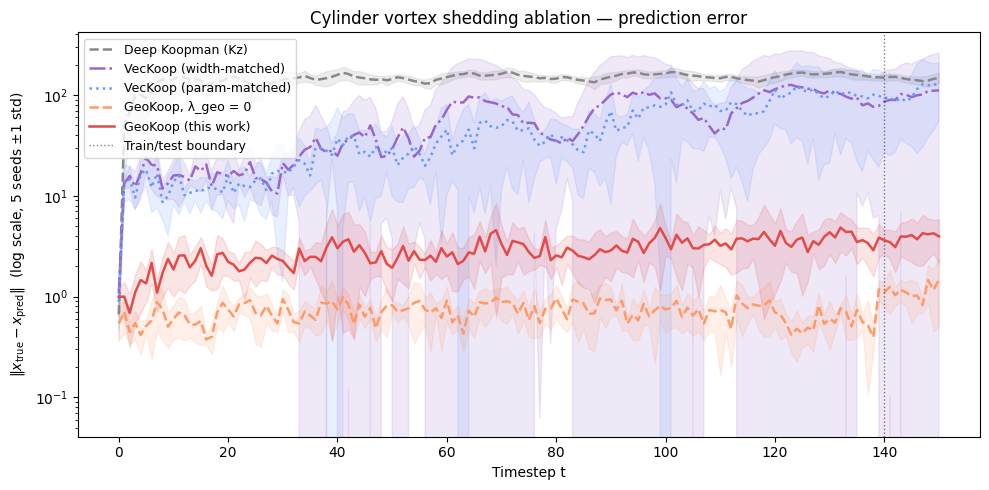

Saved /content/drive/MyDrive/Koopman/Cylinder_data/results/figures/rollout_comparison.png


In [8]:
def plot_per_t_error(summary, fname='rollout_comparison.png'):
    fig, ax = plt.subplots(figsize=(10, 5))
    ts = np.arange(T_total)

    style = {
        'deep':      ('#888888', '--', 'Deep Koopman (Kz)'),
        'vec_wm':    ('#9966CC', '-.', 'VecKoop (width-matched)'),
        'vec_pm':    ('#6699FF', ':',  'VecKoop (param-matched)'),
        'geo_nogeo': ('#FF9966', '--', 'GeoKoop, λ_geo = 0'),
        'geo':       ('#E24B4A', '-',  'GeoKoop (this work)'),
    }

    for name in ['deep', 'vec_wm', 'vec_pm', 'geo_nogeo', 'geo']:
        if name not in summary: continue
        s = summary[name]
        c, ls, label = style[name]
        m = np.array(s['err_per_t_mean'])
        sd = np.array(s['err_per_t_std'])
        ax.plot(ts, m, color=c, ls=ls, lw=1.8, label=label)
        ax.fill_between(ts, m - sd, m + sd, color=c, alpha=0.15)

    ax.axvline(N_TRAIN, color='k', ls=':', lw=1, alpha=0.5,
               label='Train/test boundary')
    ax.set_yscale('log')
    ax.set_xlabel('Timestep t')
    ax.set_ylabel(r'$\|x_\mathrm{true} - x_\mathrm{pred}\|$  (log scale, 5 seeds ±1 std)')
    ax.set_title('Cylinder vortex shedding ablation — prediction error')
    ax.legend(loc='upper left', fontsize=9)
    plt.tight_layout()
    out = os.path.join(FIGS_DIR, fname)
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {out}')

plot_per_t_error(summary)

## 9. Mechanism plot: does $N(z)$ activate where the decoder is anisotropic?

Same as the pendulum mechanism plot. For the seed-0 `geo` and `geo_nogeo`
models, scatter $\log\|N(z)\|_F$ vs $\log\kappa(G(z))$ at sampled
latent points.

**On pendulum** we got ρ ≈ 0.024 (geo_nogeo) and ρ ≈ −0.38 (geo) — no
geometric signal at all. **On cylinder** this might differ because:

- The decoder maps R^16 → R^32 instead of R^4 → R^2, so the Jacobian is
  taller and the anisotropy structure is richer.
- Cylinder is a real PDE with native spatial coherence; the latent
  geometry might genuinely correlate with physical structure (vortex
  positions, shedding phase) in a way the lifted pendulum did not.

I'm cautious about predicting the outcome. Just look at the ρ values.

Sample size reduced to 200 (from pendulum's 500) because the cylinder
Jacobian is bigger and the held-out trajectory has fewer states to
sample from (T_total − N_TRAIN ≈ 11 timesteps).


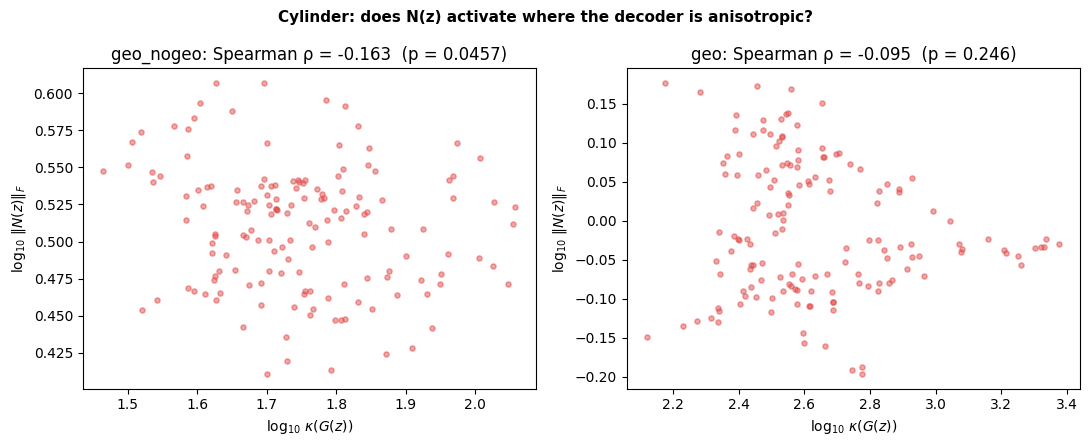

Saved /content/drive/MyDrive/Koopman/Cylinder_data/results/figures/mechanism_check.png


In [9]:
from scipy.stats import spearmanr

# Ensure seed-0 geo and geo_nogeo models are in RAM
for name in ['geo', 'geo_nogeo']:
    if name not in seed0_models:
        print(f'Retraining {name} seed=0 for mechanism plot...')
        for n, mode, hidden, lam in CONDITIONS:
            if n == name:
                seed0_models[name] = train(seed=0, mode=mode,
                                           hidden_corr=hidden, lam_geo=lam)
                break


@torch.no_grad()
def correction_frobenius(koop, z_batch):
    B = z_batch.shape[0]
    Nz = koop.correction(z_batch).view(B, koop.d, koop.d)
    return torch.norm(Nz.view(B, -1), dim=1).cpu().numpy()


def decoder_anisotropy(ae, z_batch):
    """kappa(G(z)) = lambda_max / lambda_min of J_D^T J_D at each z."""
    from torch.func import jacrev
    decode = ae.decoder
    jac_fn = jacrev(lambda z: decode(z))
    kappas = []
    for z in z_batch:
        J = jac_fn(z)                    # (R=32, d=16)
        G = J.T @ J                      # (d, d)
        eigs = torch.linalg.eigvalsh(G)
        eigs = torch.clamp(eigs, min=1e-12)
        kappas.append((eigs.max() / eigs.min()).item())
    return np.array(kappas)


def mechanism_data(result, n_samples=200):
    ae, koop = result['ae'], result['koop']
    ae.eval(); koop.eval()

    # Sample latent states from the full trajectory (training + held-out)
    with torch.no_grad():
        all_data = U_svd[:, :R].T @ vort_all          # (R, T_total)
        all_norm = (all_data - X_mean) / X_std
        all_t = torch.tensor(all_norm.T, dtype=torch.float32).to(device)
        idx = np.random.RandomState(0).choice(
            len(all_t), size=min(n_samples, len(all_t)), replace=False)
        z_samples = ae.encode(all_t[idx])

    n_fro  = correction_frobenius(koop, z_samples)
    kappas = decoder_anisotropy(ae, z_samples)
    rho, p = spearmanr(np.log(n_fro + 1e-12), np.log(kappas + 1e-12))
    return n_fro, kappas, rho, p


fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, name in zip(axes, ['geo_nogeo', 'geo']):
    n_fro, kappa, rho, p = mechanism_data(seed0_models[name])
    ax.scatter(np.log10(kappa), np.log10(n_fro + 1e-12),
               s=14, alpha=0.5, c='#E24B4A')
    ax.set_xlabel(r'$\log_{10}\,\kappa(G(z))$')
    ax.set_ylabel(r'$\log_{10}\,\|N(z)\|_F$')
    title = f'{name}: Spearman ρ = {rho:+.3f}'
    title += '  (p < 0.001)' if p < 1e-3 else f'  (p = {p:.3g})'
    ax.set_title(title)

plt.suptitle('Cylinder: does N(z) activate where the decoder is anisotropic?',
             fontsize=11, fontweight='bold')
plt.tight_layout()
out = os.path.join(FIGS_DIR, 'mechanism_check.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {out}')

## 10. After the sweep finishes — send me back

1. **The summary table** from cell 7 (just copy-paste the printed output)
2. **`rollout_comparison.png`** from cell 8
3. **`mechanism_check.png`** from cell 9 — specifically the two ρ values
   in the subplot titles

That's enough to compare against the pendulum result and decide on the
paper's framing. The branching logic:

| Pendulum | Cylinder | Conclusion |
|---|---|---|
| `geo` ≈ `vec_pm`, ρ ≈ 0 | `geo` ≈ `vec_pm`, ρ ≈ 0 | Geometric framing fails universally → rewrite as residual-correction paper (Path B) |
| `geo` ≈ `vec_pm`, ρ ≈ 0 | `geo` > `vec_pm`, ρ > 0.3 | Geometric framing holds on PDEs but not lifted ODEs → reframe with scope restriction |
| `geo` ≈ `vec_pm`, ρ ≈ 0 | `geo_nogeo` > `geo`, but `geo_nogeo` shows ρ > 0.3 | Drop the regularizer; the matrix structure does geometric work without it |
| any | mixed/inconclusive | We discuss what the data actually supports |

The pendulum data is already locked in. Cylinder decides which row above
we're in.
